# Download dataset from Kaggle

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("CooperUnion/cardataset")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/CooperUnion/cardataset/versions/1


# Use the path to read the csv file into dataframe

In [1]:
import pandas as pd
df = pd.read_csv("/home/codespace/.cache/kagglehub/datasets/CooperUnion/cardataset/versions/1/data.csv")
df.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [10]:
#clean the header to make all headers lowercase and replace spaces by _
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

# Clean the columnnames

In [2]:
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [12]:
#apply similar changes to data also
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [3]:
cols = df.dtypes[df.dtypes=="str"].index
print(cols)

Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='str')


# Clean the data

In [4]:
for col in cols:
    df[col] = df[col].str.lower().str.replace(' ','_')
df.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# Exploratory Data Analysis

In [7]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:10])
    print(df[col].nunique())

make
<StringArray>
[          'bmw',          'audi',          'fiat', 'mercedes-benz',
      'chrysler',        'nissan',         'volvo',         'mazda',
    'mitsubishi',       'ferrari']
Length: 10, dtype: str
48
model
<StringArray>
['1_series_m',   '1_series',        '100', '124_spider',  '190-class',
   '2_series',        '200',      '200sx',      '240sx',        '240']
Length: 10, dtype: str
914
year
[2011 2012 2013 1992 1993 1994 2017 1991 2016 1990]
28
engine_fuel_type
<StringArray>
[                 'premium_unleaded_(required)',
                             'regular_unleaded',
               'premium_unleaded_(recommended)',
                     'flex-fuel_(unleaded/e85)',
                                       'diesel',
                                     'electric',
 'flex-fuel_(premium_unleaded_recommended/e85)',
                                  'natural_gas',
    'flex-fuel_(premium_unleaded_required/e85)',
             'flex-fuel_(unleaded/natural_gas)']
Length: 10, 

<Axes: xlabel='msrp', ylabel='Count'>

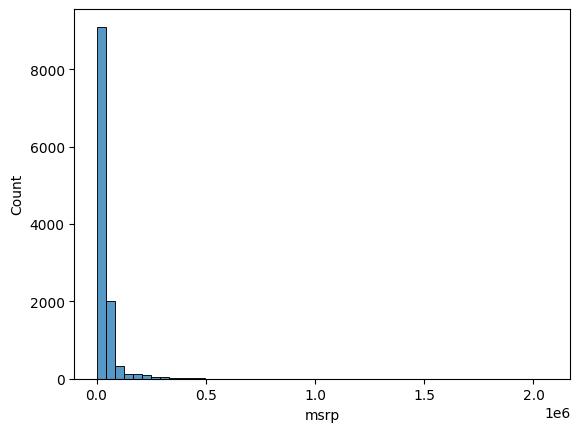

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns. histplot(df.msrp,bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

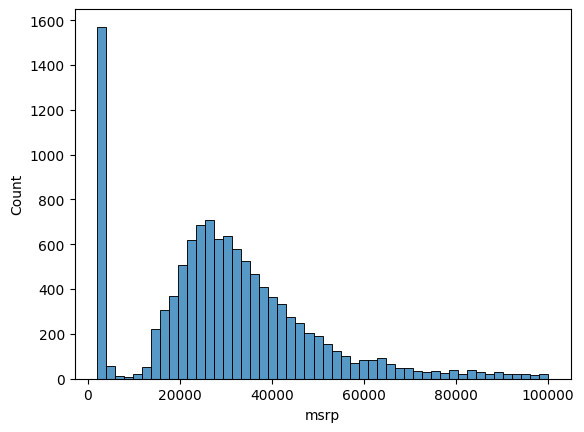

In [10]:
sns. histplot(df.msrp[df['msrp']<100000],bins=50) #to eliminate the long tail

# To get the normal distribution over the entire data apply log

<Axes: xlabel='msrp', ylabel='Count'>

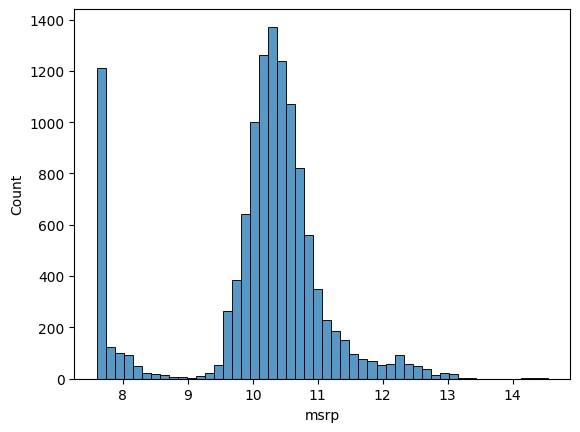

In [11]:
import numpy as np
prices = np.log1p(df.msrp) #log1p means applying log after adding 1 to values to ensure that log 0 will never occur
sns.histplot(prices,bins=50)

# Dividing the df into train, validation and test datasets

In [6]:
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - (n_val+n_test)
print(n_train,n_val,n_test)

7150 2382 2382


In [7]:
# generate the shuffled indexes
import numpy as np
idx = np.array(np.arange(0,n))
np.random.seed(2)
np.random.shuffle(idx)
print(idx, len(idx))

[2735 6720 5878 ... 6637 2575 7336] 11914


In [8]:
idx_train = idx[:n_train]
idx_val = idx[n_train:n_train+n_val]
idx_test = idx[n_train+n_val:]
df_train = df.iloc[idx_train]
df_val = df.iloc[idx_val]
df_test = df.iloc[idx_test]
print(len(df_train),len(df_test),len(df_val))

7150 2382 2382


In [30]:
df_train.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


# Reset the index and remove the old index column 

In [9]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [10]:
#extract the target from the df and store it in the target variable y
y_train = np.array(np.log1p(df_train.msrp))
y_val = np.array(np.log1p(df_val.msrp))
y_test = np.array(np.log1p(df_test.msrp))
print(y_train[:5])
#delete the target column from the dataframe
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

[ 9.57574708  9.887663    9.89323518  7.60140233 10.93775686]


In [33]:
len(y_train)

7150

Building a simple linear regression model

In [34]:
df_train.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
5,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873
6,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520
7,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916
8,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67
9,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657


In [3]:
# consider the features engine_hp, city_mpg and populaity for the 10th observation
import numpy as np
xi = [202,13,5657]
wi = [0.01,0.04,0.002] #assumed
w0 = 7.17 #assumed
def linear_regression(xi):
    pred = w0
    for j in range(len(xi)):
        pred = pred+wi[j]*xi[j]
    return pred
np.expm1(linear_regression(xi))

np.float64(1350850186.9129667)

In [4]:
np.log1p(1350850186.9129667)

np.float64(21.024)

Generalize it to all observations

Formula is g(X) approx = y; The function g(X) is given by w0x0+w1x1+w2x2+...wnxn where w0 is the bias and w1, w2, w3..wn are the weights associated with the input features. x0 is always 1.

In [5]:
x1 = [1, 202,13,5657]
x2 = [1, 150,21,1657]
x10 = [1, 250,11,657]
X = [x1,x2,x10]
X = np.array(X)
W_new = [w0]+wi
pred = X.dot(W_new)
print(pred)

[21.024 12.824 11.424]


## Training the Linear Regression model to find the bias and the weight vector

In [12]:
import numpy as np
X = np.array([
     [202,13,5657],
     [150,21,1657],
     [250,11,657],
     [230,14,775],
     [211,13,565],
     [202,13,5657],
     [155,31,1657],
     [255,11,6657],
     [112,10,570]
])

y = [100000,20000,4000000,500000,1500000,200000,300000,450000,700000]
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    W = XTX_inv.dot(X.T).dot(y)
    return W[0],W[1:]
train_linear_regression(X,y)

(np.float64(-501104.7396739385),
 array([ 14586.87732885, -41876.77844492,   -325.25368674]))

# Car price baseline model

[[1.480e+02 4.000e+00 3.300e+01 2.400e+01 1.385e+03]
 [1.320e+02 4.000e+00 3.200e+01 2.500e+01 2.031e+03]
 [1.480e+02 4.000e+00 3.700e+01 2.800e+01 6.400e+02]
 [9.000e+01 4.000e+00 1.800e+01 1.600e+01 8.730e+02]
 [3.850e+02 8.000e+00 2.100e+01 1.500e+01 5.657e+03]]
7.927257388069986 [ 9.70589522e-03 -1.59103494e-01  1.43792133e-02  1.49441072e-02
 -9.06908672e-06]


<Axes: ylabel='Count'>

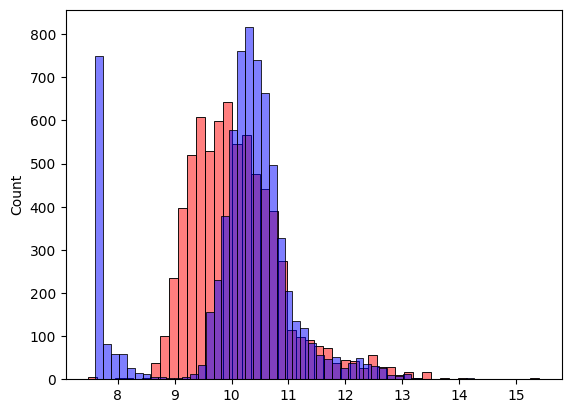

In [25]:
# consider only numerical features
X_train = df_train[['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']].fillna(0).values
print(X_train[:5])
w0, W = train_linear_regression(X_train,y_train)
print(w0,W)
y_pred = w0+X_train.dot(W)
sns.histplot(y_pred,color='red',alpha=0.5,bins=50)
sns.histplot(y_train,color='blue',alpha=0.5,bins=50)

In [16]:
def rmse(y, y_pred):
    error = y-y_pred
    se = error**2
    mse = se.mean()
    rmse = np.sqrt(mse)    
    return rmse

        

In [ ]:

rmse(y_train,y_pred)

In [33]:
x_val = df_val[['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']].fillna(0).values

In [34]:
print(x_val)

[[2.000e+02 4.000e+00 2.500e+01 1.900e+01 1.385e+03]
 [2.410e+02 4.000e+00 2.900e+01 2.200e+01 6.170e+02]
 [1.600e+02 4.000e+00 3.600e+01 2.600e+01 5.657e+03]
 ...
 [3.320e+02 8.000e+00 2.300e+01 2.000e+01 1.624e+03]
 [1.480e+02 4.000e+00 3.400e+01 2.400e+01 4.360e+02]
 [2.900e+02 6.000e+00 2.500e+01 1.800e+01 1.720e+03]]


In [35]:
y_val_pred = w0+x_val.dot(W)

In [36]:
print(y_val_pred)

[ 9.86288014 10.37013608  9.69868129 ... 10.4916625   9.57091361
 10.40022147]


In [37]:
rmse(y_val,y_val_pred)

np.float64(0.761653099130156)

In [22]:
def prepare_dataset(df):
    df = df.copy()
    df["age"] = df.year.max() - df.year
    for v in [2,3,4]:
        df['num_of_doors_%s'%v] = (df.number_of_doors==v).astype('int')
    df = df[['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity','age','num_of_doors_2','num_of_doors_3','num_of_doors_4']]
    
    df = df.fillna(0).values
    return df
X_train = prepare_dataset(df_train)
w0, w = train_linear_regression(X_train,y_train)
print(w0, w)

10.659085118454128 [ 3.71362023e-03  7.55896758e-02 -3.94226970e-03  1.05656089e-02
 -4.55063701e-05 -9.45102320e-02 -1.26327322e+00 -1.47267350e+00
 -1.30655848e+00]


In [23]:
X_val = prepare_dataset(df_val)
y_pred = w0+X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.515799564150169)

<Axes: ylabel='Count'>

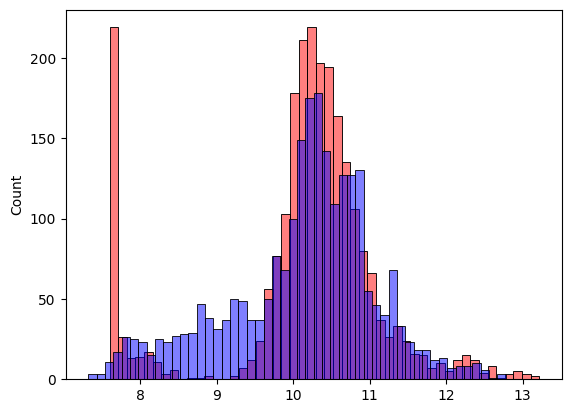

In [24]:
import seaborn as sns
sns.histplot(y_val,color='red',alpha=0.5,bins=50)
sns.histplot(y_pred,color='blue',alpha=0.5,bins=50)